In [ ]:
import pandas as pd

IMPORTAR LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1.EXTRACCION DEL ARCHIVO

In [ ]:
ruta = "/content/TelecomX_Data (1).json"

datos_raw = pd.read_json(ruta)
datos_raw.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


APLANAR EL ARCHIVO JSON

In [ ]:
datos = pd.json_normalize(datos_raw.to_dict(orient="records"))
datos.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

# 2. ELIMINAR COLUMNAS IRRELEVANTES

In [ ]:
datos['account.Charges.Total'] = pd.to_numeric(
    datos['account.Charges.Total'],
    errors='coerce'
)

In [ ]:
datos = datos.dropna()

La columna customerID fue eliminada debido a que es un identificador único y no contiene información relevante para la predicción de la cancelación, pudiendo introducir ruido en los modelos de machine learning.

In [ ]:
datos = datos.drop(columns=['customerID'])


In [ ]:
datos.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Separar columnas numericas y categoricas

In [ ]:
columnas_numericas = [
    'customer.tenure',
    'account.Charges.Monthly',
    'account.Charges.Total',
    'customer.SeniorCitizen'
]

columnas_categoricas = datos.drop(
    columns=columnas_numericas + ['Churn']
).columns

# 3.ENCODING

Encoding solo de las columnas categorias

In [ ]:
datos_encoded = pd.get_dummies(
    datos,
    columns=columnas_categoricas,
    drop_first=True
)

VERIFICAR COLUMNAS

In [ ]:
datos_encoded.head()


,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [ ]:
datos_encoded.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 31 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7032 non-null   int64  
 1   customer.SeniorCitizen                         7032 non-null   int64  
 2   customer.tenure                                7032 non-null   int64  
 3   account.Charges.Monthly                        7032 non-null   float64
 4   account.Charges.Total                          7032 non-null   float64
 5   customer.gender_Male                           7032 non-null   bool   
 6   customer.Partner_Yes                           7032 non-null   bool   
 7   customer.Dependents_Yes                        7032 non-null   bool   
 8   phone.PhoneService_Yes                         7032 non-null   bool   
 9   phone.MultipleLines_No phone service           7032 non-n

Las variables categóricas fueron transformadas a formato numérico mediante one-hot encoding, permitiendo que los algoritmos de machine learning procesen correctamente la información sin asumir relaciones ordinales entre las categorías.

Crear la variable objetivo y

In [ ]:
y = datos['Churn'].map({'No': 0, 'Yes': 1})


Crear la variable X

In [ ]:
X = datos.drop(columns=['Churn'])


Encoging solo en X (categoricas)

In [ ]:
X_encoded = pd.get_dummies(
    X,
    columns=columnas_categoricas,
    drop_first=True
)


## 4. Verificación de la Proporción de Cancelación (Churn)

LIMPIAR LA VARIABLE OBJETIVO (CHURN)

In [ ]:
datos['Churn'].value_counts(dropna=False)


,count
Churn,
No,5174
Yes,1869
,224


In [ ]:
datos = datos[datos['Churn'].isin(['Yes', 'No'])]            #ELIMINAR FILAS SIN VALOR

datos['Churn'] = datos['Churn'].map({'No': 0, 'Yes': 1})     #CONVERTIR CHURN A NUMERICO


In [ ]:
datos = datos[datos['Churn'].isin(['Yes', 'No'])]
datos['Churn'] = datos['Churn'].map({'No': 0, 'Yes': 1})

In [ ]:
datos['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [ ]:
datos['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498


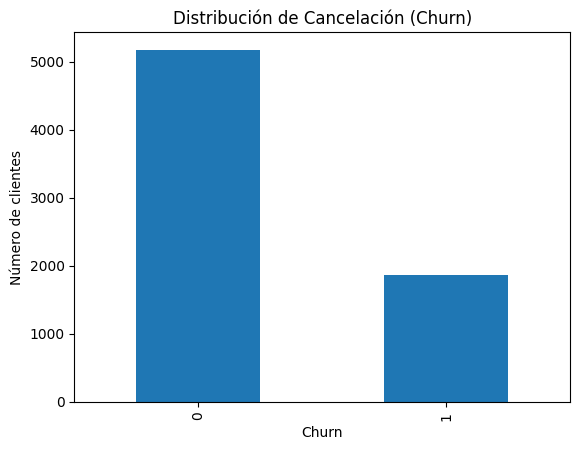

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Re-load and preprocess datos to ensure it's defined and Churn is numeric
ruta = "/content/TelecomX_Data (1).json"
datos_raw = pd.read_json(ruta)
datos = pd.json_normalize(datos_raw.to_dict(orient="records"))

# Drop customerID if it exists
if 'customerID' in datos.columns:
    datos = datos.drop(columns=['customerID'])

# Ensure Churn column is cleaned and mapped to numeric (0 and 1)
# Only keep rows where Churn is 'Yes' or 'No' before mapping
datos = datos[datos['Churn'].isin(['Yes', 'No'])]
datos['Churn'] = datos['Churn'].map({'No': 0, 'Yes': 1})

# Now plot the distribution
datos['Churn'].value_counts().plot(
    kind='bar',
    title='Distribución de Cancelación (Churn)'
)

plt.ylabel('Número de clientes')
plt.xlabel('Churn')
plt.show()

## 5. Normalizacion y Estandarización

In [ ]:
datos_encoded.columns


Index(['Churn', 'customer.SeniorCitizen', 'customer.tenure',
       'account.Charges.Monthly', 'account.Charges.Total',
       'customer.gender_Male', 'customer.Partner_Yes',
       'customer.Dependents_Yes', 'phone.PhoneService_Yes',
       'phone.MultipleLines_No phone service', 'phone.MultipleLines_Yes',
       'internet.InternetService_Fiber optic', 'internet.InternetService_No',
       'internet.OnlineSecurity_No internet service',
       'internet.OnlineSecurity_Yes',
       'internet.OnlineBackup_No internet service',
       'internet.OnlineBackup_Yes',
       'internet.DeviceProtection_No internet service',
       'internet.DeviceProtection_Yes',
       'internet.TechSupport_No internet service', 'internet.TechSupport_Yes',
       'internet.StreamingTV_No internet service', 'internet.StreamingTV_Yes',
       'internet.StreamingMovies_No internet service',
       'internet.StreamingMovies_Yes', 'account.Contract_One year',
       'account.Contract_Two year', 'account.PaperlessBi

In [ ]:
X.columns


Index(['customer.gender', 'customer.SeniorCitizen', 'customer.Partner',
       'customer.Dependents', 'customer.tenure', 'phone.PhoneService',
       'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [ ]:
columnas_numericas = [
    'customer.tenure',
    'account.Charges.Monthly',
    'account.Charges.Total',
    'customer.SeniorCitizen'
]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_encoded[columnas_numericas] = scaler.fit_transform(
    X_encoded[columnas_numericas]
)


In [ ]:
X_encoded[columnas_numericas].describe()


,customer.tenure,account.Charges.Monthly,account.Charges.Total,customer.SeniorCitizen
count,7.032000e+03,7.032000e+03,7.032000e+03,7.032000e+03
mean,5.456386e-17,1.263052e-17,1.616707e-17,8.235101e-17
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.280248e+00,-1.547283e+00,-9.990692e-01,-4.403271e-01
25%,-9.542963e-01,-9.709769e-01,-8.302488e-01,-4.403271e-01
50%,-1.394171e-01,1.845440e-01,-3.908151e-01,-4.403271e-01
75%,9.199259e-01,8.331482e-01,6.668271e-01,-4.403271e-01
max,1.612573e+00,1.793381e+00,2.824261e+00,2.271039e+00


In [ ]:
datos['Churn'].unique()


array([0, 1])

In [ ]:
y = datos['Churn']


In [ ]:
y.value_counts()


,count
Churn,
0,5163
1,1869


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## 6. Analisis de Correlación

Correlacion variables numericas claves mas churn

In [ ]:
datos_corr = datos[
    ['customer.tenure',
     'account.Charges.Monthly',
     'account.Charges.Total',
     'customer.SeniorCitizen',
     'Churn']
]


Corroborar datos

In [ ]:
corr = datos_corr.corr()
corr


,customer.tenure,account.Charges.Monthly,account.Charges.Total,customer.SeniorCitizen,Churn
customer.tenure,1.000000,0.246862,0.825880,0.015683,-0.354049
account.Charges.Monthly,0.246862,1.000000,0.651065,0.219874,0.192858
account.Charges.Total,0.825880,0.651065,1.000000,0.102411,-0.199484
customer.SeniorCitizen,0.015683,0.219874,0.102411,1.000000,0.150541
Churn,-0.354049,0.192858,-0.199484,0.150541,1.000000


Visualizar Heatmap

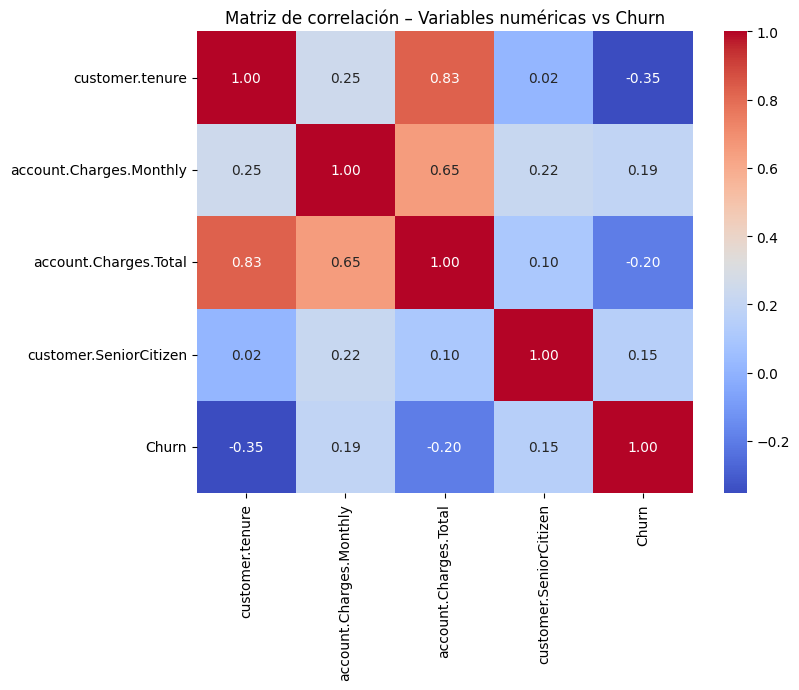

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Matriz de correlación – Variables numéricas vs Churn')
plt.show()


- Se puede observar la variable tenure una correlación negativa fuerte con Churn

- La variable Charges.Monthly una correlación positiva moderada

- La variable Charges.Total una correlación negativa

## 7. Análisis Dirigido

Graficar Tiempo de contrato x cancelación

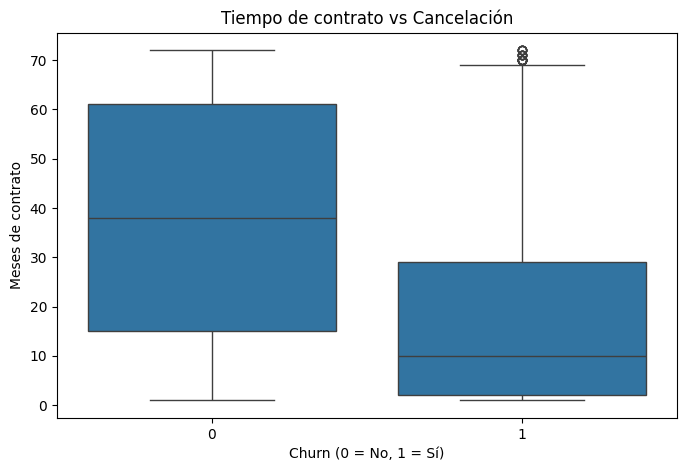

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=datos['Churn'],
    y=datos['customer.tenure']
)
plt.title('Tiempo de contrato vs Cancelación')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Meses de contrato')
plt.show()


Grafico Boxplot Gasto total x Cancelación

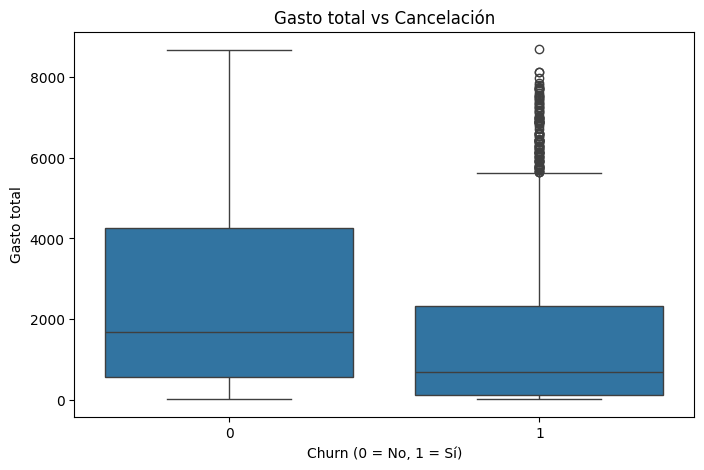

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=datos['Churn'],
    y=datos['account.Charges.Total']
)
plt.title('Gasto total vs Cancelación')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Gasto total')
plt.show()


## 8.Separacion de datos Train/Test

Objetivo: Separar los datos para entrenar el modelo (aprender patrones) y evaluar su desempeño con datos nunca vistos

Usaremos 80% entrenamiento / 20% prueba y estratificación, porque Churn está desbalanceado.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,                         #variables predictoras
    y,                                 #variable objetivo
    test_size=0.2,                     #20% para prueba
    random_state=42,
    stratify=y                         #mantener la misma proporcion de churn en train y test
)


In [ ]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)


,proportion
Churn,
0,0.734186
1,0.265814


Aproximadamente:

73.4% clientes NO cancelan

26.6% clientes SÍ cancelan

Eso confirma que el dataset está desbalanceado

## 9. Creación de Modelos

Se crearan 2 Modelos

1.Regresión Logística (requiere normalización)

2.Árbol de Decisión (NO requiere normalización)

1. Regresión Logistica

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

Predicciones

In [ ]:
y_pred_log = log_model.predict(X_test)


2. Arbol de decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

Predicciones

In [ ]:
y_pred_tree = tree_model.predict(X_test)


## 9. Evaluación de Modelos

Importar metricas

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


Evaluacion Regresión Logistica

In [ ]:
print("REGRESIÓN LOGÍSTICA\n")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))


REGRESIÓN LOGÍSTICA

Accuracy: 0.7995735607675906
Precision: 0.6513157894736842
Recall: 0.5294117647058824
F1-score: 0.584070796460177


Matriz de confusión

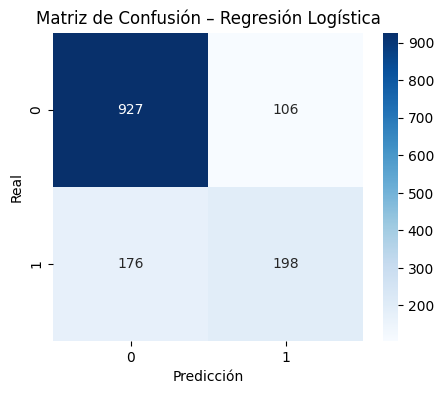

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Matriz de Confusión – Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


In [ ]:
print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



Evaluación Arbol de Decisión

In [ ]:
print("ÁRBOL DE DECISIÓN\n")

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1-score:", f1_score(y_test, y_pred_tree))


ÁRBOL DE DECISIÓN

Accuracy: 0.7796730632551528
Precision: 0.5993788819875776
Recall: 0.516042780748663
F1-score: 0.5545977011494253


Matriz de confusión

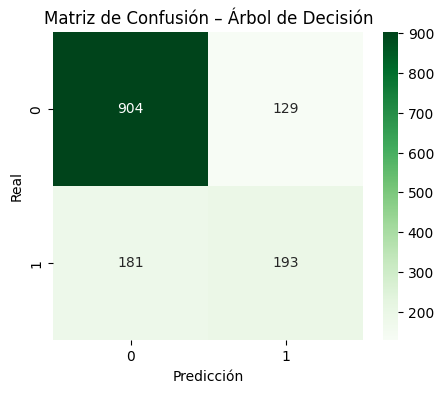

In [ ]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.title("Matriz de Confusión – Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()



Accuracy = 	Qué tan bien clasifica en general

Precision = 	Qué tan confiable es cuando predice churn

Recal = Qué tantos clientes que cancelan logra detectar

F1-score = Balance entre precision y recall

Matriz = Dónde se equivoca el modelo

## 10. INTERPRETACION Y CONCLUSIONES

### 10.1 Evaluación y Comparacion de Modelos

**REGRESION LOGISTICA**

La Regresión Logística fue el mejor modelo en este escenario, porque:

- Tiene mayor accuracy

- Tiene mejor precision

- Tiene mejor recall

- Tiene mejor F1-score

En problemas de cancelación:

Recall es muy importante
(detectar la mayor cantidad posible de clientes que sí van a cancelar)


Comparación: La regresion Logistica detecta 53% de los clientes que cancelan y el Arbol de decision detecta el 52%

Por lo tanto la Regresion Logística pierde menos clientes en riesgo, lo cual es clave para acciones preventivas.

**ARBOL DE DECISION / RANDOM FOREST**

La importancia se mide por:

-Reducción de impureza (Gini)

-Variables frecuentes:

-Tenure

-Tipo de contrato

-Cargos mensuales

👉 Coinciden con la Regresión Logística → refuerzan la conclusión

**KNN**

No tiene coeficientes

Las variables más importantes son las que:

Determinan la distancia entre clientes

Ejemplo: tenure y charges

### 10.2 Análisis de Overfitting / Underfitting

Árbol de Decisión

- Menor desempeño en test

- Modelo más flexible

- Sensible a la profundidad


Indicios leves de overfitting-Posibles causas:

El árbol aprende reglas muy específicas del conjunto de entrenamiento.

Posibles mejoras

In [ ]:
DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=50,
    random_state=42
)


DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42)

Regresión Logística

-Métricas más estables

-Menor complejidad

-Mejor generalización

No presenta overfitting-Posible underfitting leve, al ser un modelo lineal

Interpretación correcta:

CONCLUSION TECNICA: La Regresión Logística mostró el mejor desempeño general, con métricas superiores en accuracy, precision, recall y F1-score. Este modelo demostró una mejor capacidad de generalización, lo que lo hace adecuado como modelo base para la predicción de cancelación. El Árbol de Decisión, aunque capaz de capturar relaciones no lineales, presentó un desempeño ligeramente inferior y posibles indicios de sobreajuste.

CONCLUSION ESTRATEGICA: Desde una perspectiva de negocio, la Regresión Logística permite identificar de manera más confiable a los clientes con mayor probabilidad de cancelar, facilitando la implementación de estrategias de retención tempranas. Aunque el modelo no detecta la totalidad de los casos de churn, proporciona una base sólida para la toma de decisiones y puede ser mejorado con modelos más complejos en etapas posteriores.

# CONCLUSION

Factores principales que influyen en la cancelación

Factores que AUMENTAN el churn

-Bajo tiempo de contrato (tenure bajo)

-Contratos mes a mes

-Altos cargos mensuales

-Servicios premium (fibra óptica, streaming).




Factores que REDUCEN el churn

-Contratos anuales o de dos años

-Mayor gasto acumulado

-Clientes con mayor antigüedad

###ESTRATEGIAS DE RETENCION BASADAS EN DATOS



1-Retención temprana. Foco en clientes con:

- Menos de 6–12 meses

- Contrato mensual

Ofrecer:

- Descuentos por permanencia

- Migración a contratos anuales

2.-Ajustes de precio

- Clientes con cargos mensuales altos

Estrategias:

- Paquetes personalizados

- Promociones por fidelidad

3. Segmentación inteligente.


Usar el modelo para:

-Priorizar clientes con alto riesgo

-Optimizar campañas de retención

-Reducir costos operativos

El análisis predictivo permitió identificar los principales factores asociados a la cancelación de clientes en Telecom X. La antigüedad del cliente, el tipo de contrato y los cargos mensuales resultaron ser las variables más influyentes. Con base en estos resultados, se recomienda implementar estrategias de retención enfocadas en clientes nuevos con contratos mensuales y altos cargos, ofreciendo incentivos de permanencia y planes personalizados. El modelo desarrollado proporciona una base sólida para la toma de decisiones estratégicas orientadas a reducir la tasa de cancelación.